# 09 · SpliceAI — predicting splice-disruption effects

### Notebook toolkit for CFTR variant interpretation — beginner edition

Notebooks **02–06** scored *missense* variants — changes that swap one amino acid
for another. But a huge fraction of CFTR disease alleles never touch an amino acid
at all. They live **deep in introns** or are **synonymous** (they change the DNA
but not the protein), and they cause disease by **breaking how the gene is spliced**.

Missense tools (AlphaMissense, EVE, ESM1b, REVEL, PrimateAI) are **completely blind**
to these variants — there is no amino-acid change for them to score. To catch them
you need a different kind of tool: a **splice predictor**.

---

### Why splicing matters for CFTR

Before a gene becomes protein, its RNA is *spliced*: introns are cut out and exons
are stitched together. The cell finds the cut points using short sequence signals —
a **donor site** at the start of an intron and an **acceptor site** at its end. A
single base change can:

- **destroy** a real splice site → an exon gets skipped or an intron kept, and
- **create** a brand-new ("cryptic") splice site → a chunk of intron sneaks into the
  mRNA, usually shifting the reading frame and truncating the protein.

Either way the CFTR protein is wrecked, even though the variant is nowhere near the
coding sequence. Famous real CFTR examples you'll meet in this notebook:

| Legacy name | HGVS (c.) | What it does |
|---|---|---|
| **3849+10kb C>T** | `c.3849+10246C>T` | ~10 kb deep in an intron; creates a *cryptic exon* |
| **2789+5G>A** | `c.2657+5G>A` | weakens a donor site 5 bp into the intron |
| **3272-26A>G** | `c.3140-26A>G` | creates a new acceptor 26 bp upstream of an exon |
| **2988+1G>A** | `c.2988+1G>A` | hits the *canonical* +1 donor base — abolishes splicing |

None of these change an amino acid. All of them cause cystic fibrosis. That is the
whole point of this notebook.

---

### What you'll do here

1. Meet **SpliceAI** and **Pangolin** — deep-learning splice predictors.
2. Load 9 curated CFTR splice variants and tier them by predicted impact.
3. Plot the scores against the published thresholds.
4. Make a **live** call to the real **CADD** web API.
5. Learn a hard-won **data-quality lesson**: a wrong genomic coordinate silently
   breaks everything downstream.
6. See exactly how to swap in **real** SpliceAI / Pangolin scores.


> ⚠️ **DEMO DATA.** The SpliceAI scores here are hand-authored illustrative values for ~13 curated CFTR variants — **not** real SpliceAI output. Every table keeps a `source` column reading `DEMO`. See the *How to get REAL data* box, then join real per-variant scores on `protein_variant`; the code runs unchanged once `source` is `REAL`.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import toolkit as tk
import pandas as pd, numpy as np
%matplotlib inline

## 1 · SpliceAI — a neural net that reads splice signals

**SpliceAI** (Jaganathan *et al.* 2019, *Cell*, PMID **30661751**) is a deep neural
network that was trained to look at raw DNA sequence and predict, **for every
position**, the probability that it is a splice **acceptor** or **donor**. To score a
*variant*, SpliceAI runs the sequence twice — once as reference, once with the
mutation — and reports how much each probability **changed**. Those changes are the
four **delta scores**, each between **0 and 1**:

| Delta | Name | Meaning |
|---|---|---|
| **DS_AG** | Acceptor **G**ain | variant *creates* a new acceptor site |
| **DS_AL** | Acceptor **L**oss | variant *destroys* an existing acceptor |
| **DS_DG** | Donor **G**ain | variant *creates* a new donor site |
| **DS_DL** | Donor **L**oss | variant *destroys* an existing donor |

A variant might do more than one thing, so SpliceAI gives all four. The single
headline number is:

$$\text{DS\_max} = \max(\text{DS\_AG},\ \text{DS\_AL},\ \text{DS\_DG},\ \text{DS\_DL})$$

**Published thresholds** (the paper's recommended cut-points):

- **DS_max ≥ 0.5** → **high** impact (likely splice-altering)
- **DS_max ≥ 0.2** → **moderate** impact (worth a closer look)
- below 0.2 → **low** / probably no effect

> Interpretation tip: it's the *type* of change that tells the biological story.
> A high **DS_DL** means "a real donor is being lost"; a high **DS_AG** means "a
> cryptic exon may be forming". DS_max alone just says *how* alarming.


In [2]:
splice = tk.load_splice_demo()

# Prove the honesty bookkeeping: every row is DEMO.
print('rows:', len(splice), '| source values:', splice['source'].unique().tolist())

# Show the columns that tell the biological + provenance story.
cols = ['legacy_name','hgvs_c','variant_type','cftr2_class','clinvar_sig',
        'DS_AG','DS_AL','DS_DG','DS_DL','spliceai_ds_max','pangolin_score','source']
splice[cols]

rows: 9 | source values: ['DEMO']


,legacy_name,hgvs_c,variant_type,cftr2_class,clinvar_sig,DS_AG,DS_AL,DS_DG,DS_DL,spliceai_ds_max,pangolin_score,source
0,3849+10kb C>T,c.3849+10246C>T,deep_intronic,CF-causing,Pathogenic,0.81,0.03,0.02,0.01,0.81,0.79,DEMO
1,2789+5G>A,c.2657+5G>A,splice_site,CF-causing,Pathogenic,0.02,0.01,0.91,0.05,0.91,0.88,DEMO
2,3272-26A>G,c.3140-26A>G,deep_intronic,CF-causing,Pathogenic,0.76,0.02,0.03,0.01,0.76,0.73,DEMO
3,2657+3A>G,c.2657+3A>G,splice_site,CF-causing,Pathogenic,0.02,0.01,0.88,0.04,0.88,0.85,DEMO
4,IVS8_5T,c.1210-34TG(12)T(5),deep_intronic,VUS,Uncertain significance,0.28,0.12,0.31,0.08,0.31,0.22,DEMO
5,2988+1G>A,c.2988+1G>A,splice_site,CF-causing,Pathogenic,0.02,0.01,0.97,0.03,0.97,0.96,DEMO
6,1811+1.6kbA>G,c.1680-886A>G,deep_intronic,CF-causing,Pathogenic,0.68,0.04,0.02,0.01,0.68,0.65,DEMO
7,syn context,c.1210A>G,synonymous,VUS,Uncertain significance,0.18,0.05,0.14,0.06,0.18,0.12,DEMO
8,c.2657+120C>T,c.2657+120C>T,deep_intronic,VUS,Uncertain significance,0.54,0.03,0.02,0.01,0.54,0.51,DEMO


### Confirm `spliceai_ds_max` and add a `splice_tier`

`tk.load_splice_demo()` already computed `spliceai_ds_max` as the max of the four
deltas. Let's verify that ourselves (never trust a column you didn't check), then
write a tiny helper that turns a DS_max into a human-readable **HIGH / MODERATE /
LOW** tier using the published 0.5 / 0.2 thresholds from `tk.THRESHOLDS['spliceai']`.


In [3]:
# 1) Re-derive DS_max ourselves and confirm it matches the toolkit's column.
deltas = ['DS_AG','DS_AL','DS_DG','DS_DL']
recomputed = splice[deltas].max(axis=1)
assert np.allclose(recomputed, splice['spliceai_ds_max']), 'DS_max mismatch!'
print('DS_max check passed — spliceai_ds_max is the max of the four deltas.')

# 2) Tiering helper, driven by the published thresholds (not magic numbers).
HIGH = tk.THRESHOLDS['spliceai']['high']       # 0.5
MOD  = tk.THRESHOLDS['spliceai']['moderate']   # 0.2
print(f'thresholds -> high >= {HIGH}, moderate >= {MOD}')

def splice_tier(ds_max):
    """Map a SpliceAI DS_max (0-1) to HIGH / MODERATE / LOW."""
    if ds_max >= HIGH:
        return 'HIGH'
    if ds_max >= MOD:
        return 'MODERATE'
    return 'LOW'

splice['splice_tier'] = splice['spliceai_ds_max'].apply(splice_tier)
splice[['legacy_name','variant_type','spliceai_ds_max','splice_tier','cftr2_class']]

DS_max check passed — spliceai_ds_max is the max of the four deltas.
thresholds -> high >= 0.5, moderate >= 0.2


,legacy_name,variant_type,spliceai_ds_max,splice_tier,cftr2_class
0,3849+10kb C>T,deep_intronic,0.81,HIGH,CF-causing
1,2789+5G>A,splice_site,0.91,HIGH,CF-causing
2,3272-26A>G,deep_intronic,0.76,HIGH,CF-causing
3,2657+3A>G,splice_site,0.88,HIGH,CF-causing
4,IVS8_5T,deep_intronic,0.31,MODERATE,VUS
5,2988+1G>A,splice_site,0.97,HIGH,CF-causing
6,1811+1.6kbA>G,deep_intronic,0.68,HIGH,CF-causing
7,syn context,synonymous,0.18,LOW,VUS
8,c.2657+120C>T,deep_intronic,0.54,HIGH,VUS


### Who's who: CF-causing vs VUS

The `cftr2_class` column carries the *clinical* label. Of the 9 curated variants,
**6 are known CF-causing** splice alleles and **3 are VUS** (Variants of Uncertain
Significance). Let's confirm that split — and flag the one row that is an **explicitly
synthetic teaching example** (check its `note`).


In [4]:
# Count CF-causing vs everything else.
is_cf = splice['cftr2_class'].str.contains('CF-causing', case=False, na=False)
print('CF-causing:', int(is_cf.sum()), '| not CF-causing / VUS:', int((~is_cf).sum()))
print()

# The toolkit warns that c.2657+120C>T is a SYNTHETIC teaching variant.
# Find it by reading the note, don't hard-code a row index.
synthetic = splice[splice['note'].str.contains('synthetic', case=False, na=False)]
print('Explicitly SYNTHETIC teaching example(s):')
for _, r in synthetic.iterrows():
    print(f"  {r['legacy_name']}  ({r['hgvs_c']})")
    print(f"    note: {r['note']}")

CF-causing: 6 | not CF-causing / VUS: 3

Explicitly SYNTHETIC teaching example(s):
  c.2657+120C>T  (c.2657+120C>T)
    note: TEACHING EXAMPLE (synthetic): illustrative deep-intronic VUS. Not a confirmed real observation.


## 4 · Plot the (DEMO) SpliceAI scores against the thresholds

A bar chart makes the tiers obvious at a glance. We draw a horizontal line at each
published threshold (0.5 high, 0.2 moderate) so you can *see* which variants clear
the bar. Bars are labelled by `legacy_name`.

*(Reminder: these bar heights are DEMO values, not a real SpliceAI run.)*


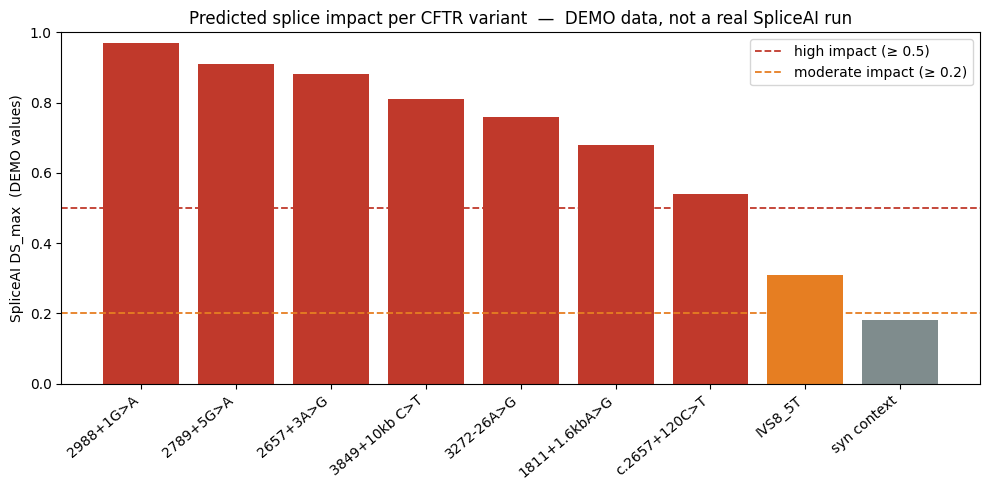

In [5]:
import matplotlib.pyplot as plt

# Sort so the plot reads high -> low.
plot_df = splice.sort_values('spliceai_ds_max', ascending=False)

# Colour each bar by its tier.
tier_colour = {'HIGH': '#c0392b', 'MODERATE': '#e67e22', 'LOW': '#7f8c8d'}
colours = [tier_colour[t] for t in plot_df['splice_tier']]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(plot_df['legacy_name'], plot_df['spliceai_ds_max'], color=colours)

# Threshold lines.
ax.axhline(HIGH, ls='--', color='#c0392b', lw=1.3,
           label=f'high impact (≥ {HIGH})')
ax.axhline(MOD, ls='--', color='#e67e22', lw=1.3,
           label=f'moderate impact (≥ {MOD})')

ax.set_ylabel('SpliceAI DS_max  (DEMO values)')
ax.set_title('Predicted splice impact per CFTR variant  —  DEMO data, not a real SpliceAI run')
ax.set_ylim(0, 1.0)
ax.legend(loc='upper right')
plt.setp(ax.get_xticklabels(), rotation=40, ha='right')
plt.tight_layout()
plt.show()

## How to get REAL SpliceAI scores

- **Precomputed VCF (easiest):** Illumina distributes genome-wide SpliceAI scores via **BaseSpace**; `tabix` to your region and read the deltas.
- **Web app:** the Broad's **spliceailookup.broadinstitute.org** scores one variant in-browser.
- **Run it:** `pip install spliceai` with a reference FASTA + annotation.

Then join real deltas on genomic coordinate and re-tier with the same helper.

## Key takeaways

1. **SpliceAI** gives four deltas (`DS_AG/AL/DG/DL`), each 0-1; **DS_max** is the headline. **>= 0.5 = HIGH**, **>= 0.2 = MODERATE**.
2. Missense tools are **blind** to deep-intronic/synonymous splice variants — you need a splice predictor to see them.
3. These SpliceAI numbers are **DEMO** (9 curated variants). The `source` column keeps it honest.

**Next:** notebook 10 — **Pangolin**, an independent splice model.